In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import *
from src.utils.helper_functions import *
from src.pipeline.props_pipeline.ppm_pipeline import *
from src.pipeline.props_pipeline.min_pipeline import *
from src.features.feature_engineer.ppm_features import ppm_features

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

s23 = pd.read_csv('data/raw/season_stats/S23.csv').sort_values(by='GAME_DATE')
s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
s25['STARTING'] = s25['START_POSITION'].notna().astype(int)
s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
s26['STARTING'] = s26['START_POSITION'].notna().astype(int)
s26.tail()

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,pos,age,STARTING
210,2025-26,1629599,Amir Coffey,Amir,1610612756,PHX,Phoenix Suns,22501185,2026-04-10T00:00:00,PHX @ LAL,L,20.550000,3,6,0.500,1,2,0.500,0,0,0.000,0,2,2,0,1,1,0,0,2,0,7,-11,11.4,0,0,12.0,1,20:33,1,82.4,82.9,82.9,114.2,115.4,115.4,-31.8,-32.5,-32.5,0.000,0.0,0.0,0.000,0.118,0.051,14.3,14.3,0.583,0.583,0.146,0.155,94.22,93.43,77.86,93.43,0.056,41,3.0,6.0,26,77,0.338,7,40,0.175,14,21,0.667,18,29,47,17,23.0,8,1,3,18,18,73,-28.0,80.0,81.1,113.2,112.2,-33.2,-31.1,0.654,0.74,13.2,0.400,0.816,0.570,0.256,0.383,0.423,90.2,90.0,75.00,90,0.255,1610612747,LAL,Los Angeles Lakers,35,69,0.507,8,20,0.400,23,30,0.767,4,31,35,27,11.0,17,3,1,18,18,101,28.0,113.2,112.2,80.0,81.1,33.2,31.1,0.771,2.45,21.8,0.184,0.600,0.430,0.122,0.565,0.614,90.2,90.0,75.00,90,0.745,NaN,SG,28.0,0
211,2025-26,1627739,Kris Dunn,Kris,1610612746,LAC,LA Clippers,22501183,2026-04-10T00:00:00,LAC @ POR,L,26.566667,2,3,0.667,1,2,0.500,0,0,0.000,1,4,5,1,2,0,0,0,4,1,5,3,10.5,0,0,12.0,1,26:34,1,128.6,131.4,131.4,117.5,123.1,123.1,11.2,8.3,8.3,0.043,0.5,16.7,0.042,0.143,0.096,33.3,33.3,0.833,0.833,0.088,0.086,96.26,93.05,77.54,93.05,0.031,51,2.0,3.0,36,83,0.434,13,40,0.325,12,12,1.000,10,25,35,17,17.0,6,3,7,27,15,97,-19.0,101.8,102.1,116.7,122.1,-14.9,-20.0,0.472,1.00,13.8,0.250,0.574,0.411,0.179,0.512,0.549,97.3,95.0,79.17,95,0.350,1610612757,POR,Portland Trail Blazers,37,83,0.446,12,39,0.308,30,35,0.857,14,32,46,23,15.0,12,7,3,15,27,116,19.0,116.7,122.1,101.8,102.1,14.9,20.0,0.622,1.53,16.8,0.426,0.750,0.589,0.158,0.518,0.589,97.3,95.0,79.17,95,0.650,G,PG,31.0,1
212,2025-26,1641771,Jalen Slawson,Jalen,1610612754,IND,Indiana Pacers,22501175,2026-04-10T00:00:00,IND vs. PHI,L,15.183333,0,4,0.000,0,2,0.000,2,2,1.000,2,3,5,3,5,0,1,0,2,3,2,-14,10.5,0,0,12.0,1,15:11,1,59.0,59.4,59.4,101.9,100.0,100.0,-42.8,-40.6,-40.6,0.500,0.6,23.1,0.111,0.125,0.119,38.5,38.8,0.000,0.205,0.270,0.273,102.11,102.74,85.62,102.74,-0.041,32,0.0,4.0,33,88,0.375,14,50,0.280,14,16,0.875,10,42,52,25,21.0,6,8,2,15,14,94,-11.0,88.6,89.5,100.6,101.0,-12.0,-11.4,0.758,1.19,17.5,0.228,0.723,0.492,0.200,0.455,0.495,105.2,104.5,87.08,105,0.456,1610612755,PHI,Philadelphia 76ers,42,104,0.404,5,29,0.172,16,19,0.842,16,42,58,17,8.0,13,2,8,14,15,105,11.0,100.6,101.0,88.6,89.5,12.0,11.4,0.405,2.13,12.2,0.277,0.772,0.508,0.077,0.428,0.467,105.2,104.5,87.08,104,0.544,NaN,SF,26.0,0
205,2025-26,1642362,Payton Sandfort,Payton,1610612760,OKC,

In [3]:
res = []
for df in [s23, s24, s25, s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)

    # Derived features
    df['MIN'] = df['MIN'].round(2)
    df["PTS_PER_MIN"] = df["PTS"] / df["MIN"].replace(0, np.nan)
    df['PTS_PER_POSS'] = df['PTS'] / df['POSS'].replace(0, np.nan)
    df['FGA_PER_MIN'] = df['FGA'] / df['MIN'].replace(0, np.nan)
    df['3PA_PER_MIN'] = df['FG3A'] / df['MIN'].replace(0, np.nan)
    df['FTA_PER_MIN'] = df['FTA'] / df['MIN'].replace(0, np.nan)
    # df['STARTING'] = df['START_POSITION'].notna().astype(int)
    # df['BAYES_PPM_PROJ'] = apply_bayesian_ppm(df)
    df = ppm_features(df)
    df['TEAM_PTS_PER_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_PER_MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_PTS_PER_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_PER_MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_TS_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['TS_PCT_roll10'].rank(ascending=False, method='dense'))
    df['TRUE_USG_L10'] = df['POSS_roll10'] / df['TEAM_POSS_roll10']

    df["PTS_PER_MIN_10_ewm"] = df.groupby("PLAYER_ID")["PTS_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=10).mean())
    df["PTS_PER_MIN_5_ewm"] = df.groupby("PLAYER_ID")["PTS_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=5).mean())
    df["PTS_PER_MIN_3_ewm"] = df.groupby("PLAYER_ID")["PTS_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=3).mean())
    df['PPM_MOMENTUM'] = df['PTS_PER_MIN_5_ewm'] - df['PTS_PER_MIN_10_ewm']

    df['POSS_DIFF_L10'] = df['POSS_roll10'] - df['TEAM_POSS_roll10']
    df['TS_PCT_DELTA'] = df['TS_PCT_roll10'] - df['TEAM_TS_PCT_roll10']

    df["FGA_PER_MIN_10_ewm"] = df.groupby("PLAYER_ID")["FGA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=10).mean())
    df["FGA_PER_MIN_5_ewm"] = df.groupby("PLAYER_ID")["FGA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=5).mean())
    
    df["3PA_PER_MIN_10_ewm"] = df.groupby("PLAYER_ID")["3PA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=10).mean())
    df["FTA_PER_MIN_10_ewm"] = df.groupby("PLAYER_ID")["FTA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=10).mean())
    df["GP"] = df.groupby("PLAYER_ID").cumcount()
    le = LabelEncoder()
    df['POSITION_ENC'] = le.fit_transform(df['pos'])

    player_avgs = df[df['MIN'] > 0].groupby('PLAYER_ID')['MIN'].apply(
    lambda x: (x >= 12).mean())
    eligible = player_avgs[player_avgs >= 0.60].index
    df = df[df['PLAYER_ID'].isin(eligible)]
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df.tail()

(84270, 269)


,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,pos,age,STARTING,PTS_PER_MIN,PTS_PER_POSS,FGA_PER_MIN,3PA_PER_MIN,FTA_PER_MIN,MIN_roll3,PTS_roll3,USG_PCT_roll3,PLUS_MINUS_roll3,POSS_roll3,PTS_PER_MIN_roll3,PTS_PER_POSS_roll3,TS_PCT_roll3,AST_TO_roll3,FGA_PER_MIN_roll3,3PA_PER_MIN_roll3,FTA_PER_MIN_roll3,AST_roll3,TOV_roll3,MIN_roll5,PTS_roll5,USG_PCT_roll5,PLUS_MINUS_roll5,POSS_roll5,PTS_PER_MIN_roll5,PTS_PER_POSS_roll5,TS_PCT_roll5,AST_TO_roll5,FGA_PER_MIN_roll5,3PA_PER_MIN_roll5,FTA_PER_MIN_roll5,AST_roll5,TOV_roll5,MIN_roll10,PTS_roll10,USG_PCT_roll10,PLUS_MINUS_roll10,POSS_roll10,PTS_PER_MIN_roll10,PTS_PER_POSS_roll10,TS_PCT_roll10,AST_TO_roll10,FGA_PER_MIN_roll10,3PA_PER_MIN_roll10,FTA_PER_MIN_roll10,AST_roll10,TOV_roll10,MIN_lag1,PTS_lag1,PLUS_MINUS_lag1,PIE_lag1,STARTING_lag1,POSS_lag1,USG_PCT_lag1,MIN_lag2,PTS_lag2,PLUS_MINUS_lag2,PIE_lag2,STARTING_lag2,POSS_lag2,USG_PCT_lag2,STARTER_ROLL10_PCT,MIN_season_avg,PTS_season_avg,USG_PCT_season_avg,POSS_season_avg,PF_season_avg,OFF_RATING_season_avg,DEF_RATING_season_avg,PTS_PER_MIN_season_avg,NET_RATING_roll5,TEAM_PACE_roll10,TEAM_PTS_roll10,TEAM_POSS_roll10,TEAM_TS_PCT_roll10,MIN_share_proxy,PTS_share_proxy,DAYS_REST,IS_B2B,IS_HOME,GAME_NUMBER,MIN_std10,OPP_DEF_RATING_roll5,OPP_DEF_RATING_roll10,OPP_PACE_roll5,OPP_PACE_roll10,OPP_POSS_roll5,OPP_POSS_roll10,EXPECTED_PACE,PACE_DIFFERENTIAL,IS_TOP_STAR,ACTIVE_STARS_COUNT,TEAM_PTS_PER_MIN_RANK_L5,TEAM_PTS_PER_MIN_RANK_L10,TEAM_MIN_RANK_L10,TEAM_MIN_RANK_L5,TEAM_USG_RANK_L10,TEAM_TS_RANK_L10,TRUE_USG_L10,PTS_PER_MIN_10_ewm,PTS_PER_MIN_5_ewm,PTS_PER_MIN_3_ewm,PPM_MOMENTUM,POSS_DIFF_L10,TS_PCT_DELTA,FGA_PER_MIN_10_ewm,FGA_PER_MIN_5_ewm,3PA_PER_MIN_10_ewm,FTA_PER_MIN_10_ewm,GP,POSITION_ENC,START_POSITION
84265,2025-26,1643253,Toby Okani,Toby,1610612763,MEM,Memphis Grizzlies,22501125,2026-04-03,MEM vs. TOR,L,28.38,3,8,0.375,1,3,0.333,0,0,0.00,3,4,7,0,0,1,1,1,3,0,7,-14,21.4,0,0,19.0,1,28:23,1,91.2,90.6,90.6,114.7,114.3,114.3,-23.5,-23.7,-23.7,0.000,0.0,0.0,0.091,0.125,0.108,0.0,0.0,0.438,0.438,0.107,0.110,106.85,107.39,89.49,107.39,0.063,64,3.0,8.0,34,85,0.400,11,42,0.262,17,26,0.654,13,25,38,14,20.0,6,3,6,31,21,96,-32.0,92.8,93.2,126.7,125.5,-33.9,-32.3,0.412,0.70,10.5,0.302,0.617,0.450,0.194,0.465,0.498,102.2,102.5,85.42,103,0.230,1610612761,TOR,Toronto Raptors,44,84,0.524,9,24,0.375,31,41,0.756,17,34,51,31,16.0,10,6,3,21,31,128,32.0,126.7,125.5,92.8,93.2,33.9,32.3,0.705,1.94,20.7,0.383,0.698,0.550,0.157,0.577,0.627,102.2,102

In [ ]:
PPM_FEATURES = [       
    'STARTING',
    'PTS_PER_MIN_season_avg',  #new
    'PTS_PER_MIN_10_ewm',         
    'PPM_MOMENTUM',               
    'PTS_PER_POSS_roll10',
    'TEAM_PTS_PER_MIN_RANK_L10',
    'USG_PCT_roll10',            
    '3PA_PER_MIN_10_ewm',  
    'FTA_PER_MIN_10_ewm', #new addition      
    'TEAM_USG_RANK_L10',          
    'POSS_DIFF_L10',
    'TS_PCT_DELTA',
    'TRUE_USG_L10',
    'TS_PCT_roll10',             
    'OPP_DEF_RATING_roll10',        
    'PACE_DIFFERENTIAL',                
    'POSITION_ENC',               
    'IS_TOP_STAR', # new addition
    'ACTIVE_STARS_COUNT'  # new addition
]

In [5]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define which features to scale (Continuous) vs ignore (Binary/Ordinal)
binary_cols = ['STARTING', 'IS_TOP_STAR', 'ACTIVE_STARS_COUNT', 'POSITION_ENC', 'TEAM_PTS_PER_MIN_RANK_L10', 'TEAM_USG_RANK_L10']
continuous_cols = [c for c in PPM_FEATURES if c not in binary_cols]

ppm_df = df[PPM_FEATURES + ["PTS_PER_MIN", "MIN", "GAME_DATE"]].dropna()

# 2. Split Data
split_date = ppm_df["GAME_DATE"].quantile(0.75)
train_mask = ppm_df["GAME_DATE"] <= split_date
val_mask = ~train_mask

X_train = ppm_df.loc[train_mask, PPM_FEATURES].copy()
X_val = ppm_df.loc[val_mask, PPM_FEATURES].copy()
y_train = ppm_df.loc[train_mask, "PTS_PER_MIN"]
y_val = ppm_df.loc[val_mask, "PTS_PER_MIN"]

# 3. Apply Scaling (Only to continuous features)
scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_val[continuous_cols] = scaler.transform(X_val[continuous_cols])

# 4. Training Loop
quantiles = [0.10, 0.50, 0.90]
quantile_models = {}
quantile_preds = {}

for q in quantiles:
    print(f"Training Quantile: {q}...")
    xgb_q = XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=q,
        n_estimators=1085,
        max_depth=3,
        learning_rate=0.016830306319220507,
        subsample=0.560576121654833,
        colsample_bytree=0.7918682725578758,
        reg_alpha=0.2923179330388192,
        reg_lambda=0.16891787981446876,
        min_child_weight=2,
        n_jobs=-1,
        random_state=42
    )
    xgb_q.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    quantile_models[f"q_{q:.2f}"] = xgb_q
    quantile_preds[f"q_{q:.2f}"] = xgb_q.predict(X_val)

# 5. Diagnostic Output
results = X_val.copy()
results["Actual"] = y_val.values
results["Lower_10"] = quantile_preds["q_0.10"]
results["Median_50"] = quantile_preds["q_0.50"]
results["Upper_90"] = quantile_preds["q_0.90"]

mae = mean_absolute_error(y_val, results["Median_50"])
print(f"\nMedian Model MAE: {mae:.3f} PTS/min")
print(f"Median Model R2: {r2_score(y_val, results['Median_50']):.3f}")


Training Quantile: 0.1...
Training Quantile: 0.5...
Training Quantile: 0.9...

Median Model MAE: 0.171 PTS/min
Median Model R2: 0.273


In [7]:
# import optuna

# def objective(trial):
#     # 1. Define the search space
#     params = {
#         "max_depth": trial.suggest_int("max_depth", 3, 10),
#         "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
#         "n_estimators": trial.suggest_int("n_estimators", 500, 1500),
#         "subsample": trial.suggest_float("subsample", 0.5, 0.9),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.9),
#         "reg_alpha": trial.suggest_float("reg_alpha", 0.01, 1.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 0.01, 1.0, log=True),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
#     }
    
#     # 2. Train model with trial parameters
#     model = XGBRegressor(
#         objective="reg:quantileerror",
#         quantile_alpha=0.50, # Tune the Median model
#         **params,
#         n_jobs=-1,
#         random_state=42
#     )
    
#     model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    
#     # 3. Use MAE as the metric to minimize
#     preds = model.predict(X_val)
#     return mean_absolute_error(y_val, preds)

# # 4. Execute the study
# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=50)

# print("Best Parameters:", study.best_params)

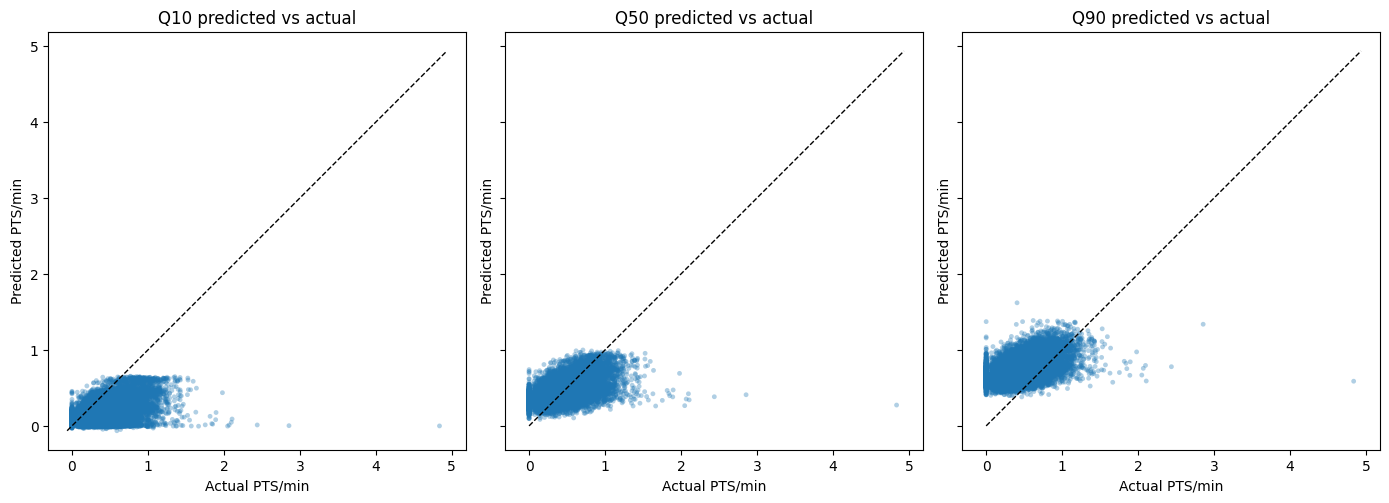

Q10 P(y ≤ pred): 0.10879430179792061
Q50 P(y ≤ pred): 0.49796082486070425
Q90 P(y ≤ pred): 0.896547762651502
Coverage (10–90 interval): 78.78%


In [6]:
import matplotlib.pyplot as plt

y_true = y_val
preds = {
    "Q10": quantile_preds["q_0.10"],
    "Q50": quantile_preds["q_0.50"],
    "Q90": quantile_preds["q_0.90"],
}

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_true, y_pred, s=12, edgecolors="none", alpha=0.35)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    lims = [lo, hi * 1.02 if hi > 0 else hi + 0.01]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name} predicted vs actual")
    ax.set_xlabel("Actual PTS/min")
    ax.set_ylabel("Predicted PTS/min")
    ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

for name, y_pred in preds.items():
    print(name, "P(y ≤ pred):", (y_true <= y_pred).mean())

pred_low = quantile_preds["q_0.10"]
pred_mid = quantile_preds["q_0.50"]
pred_high = quantile_preds["q_0.90"]

coverage = ((y_true >= pred_low) & (y_true <= pred_high)).mean()
print(f"Coverage (10–90 interval): {coverage:.2%}")  # target ~80%

Generating Global SHAP Summary Plot...


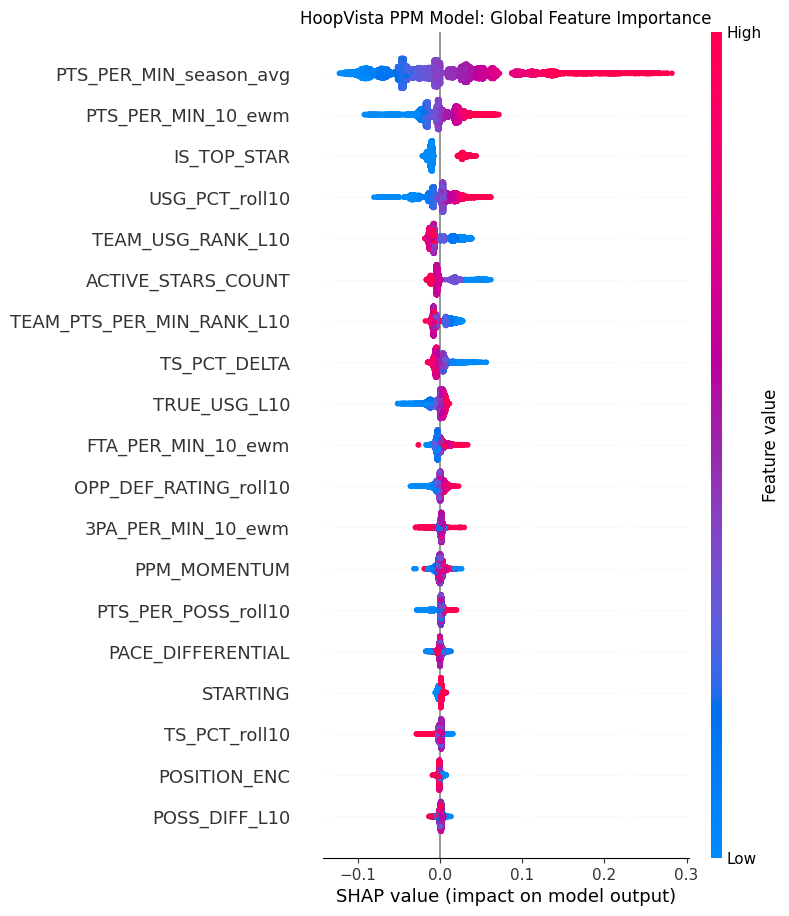

Generating Waterfall Plot for index 1154...


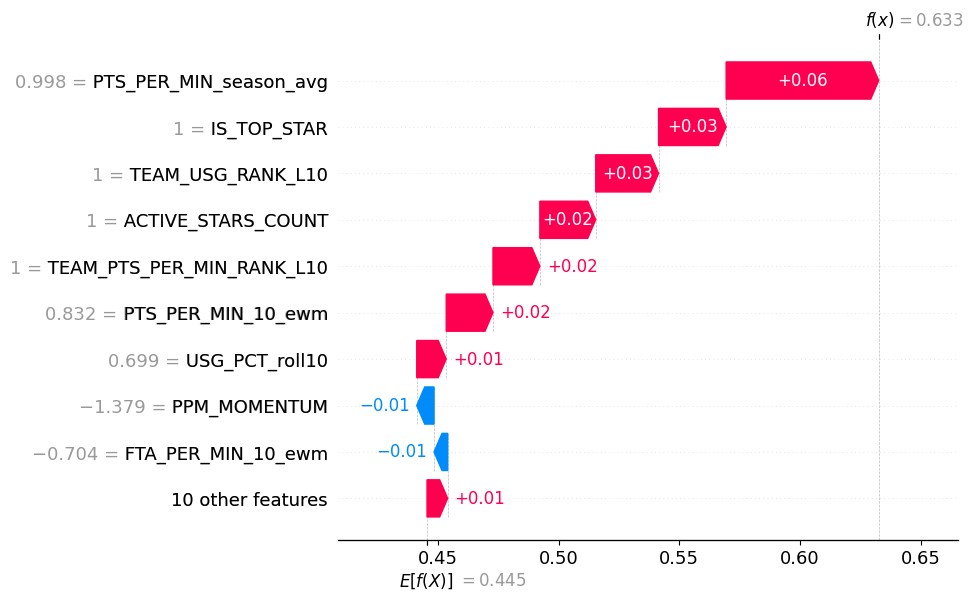

In [7]:
import shap
import matplotlib.pyplot as plt

# 1. Select the specific quantile model
model = quantile_models["q_0.50"]

# 2. Use the unscaled DataFrame to keep features human-readable
# Note: Ensure X_val_ppm index aligns with the data used to train the model
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val) 

# 3. Global Summary Plot
# Use plot_type='dot' for a cleaner look at feature interactions
print("Generating Global SHAP Summary Plot...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val, show=False)
plt.title("HoopVista PPM Model: Global Feature Importance")
plt.show()

# 4. Local Waterfall Plot
# check_additivity=False is recommended if your model has custom objectives 
# or complex interaction constraints that SHAP's fast path struggles with.
row_idx = 1154
print(f"Generating Waterfall Plot for index {row_idx}...")
plt.figure(figsize=(8, 6))
shap.plots.waterfall(shap_values[row_idx], show=True)

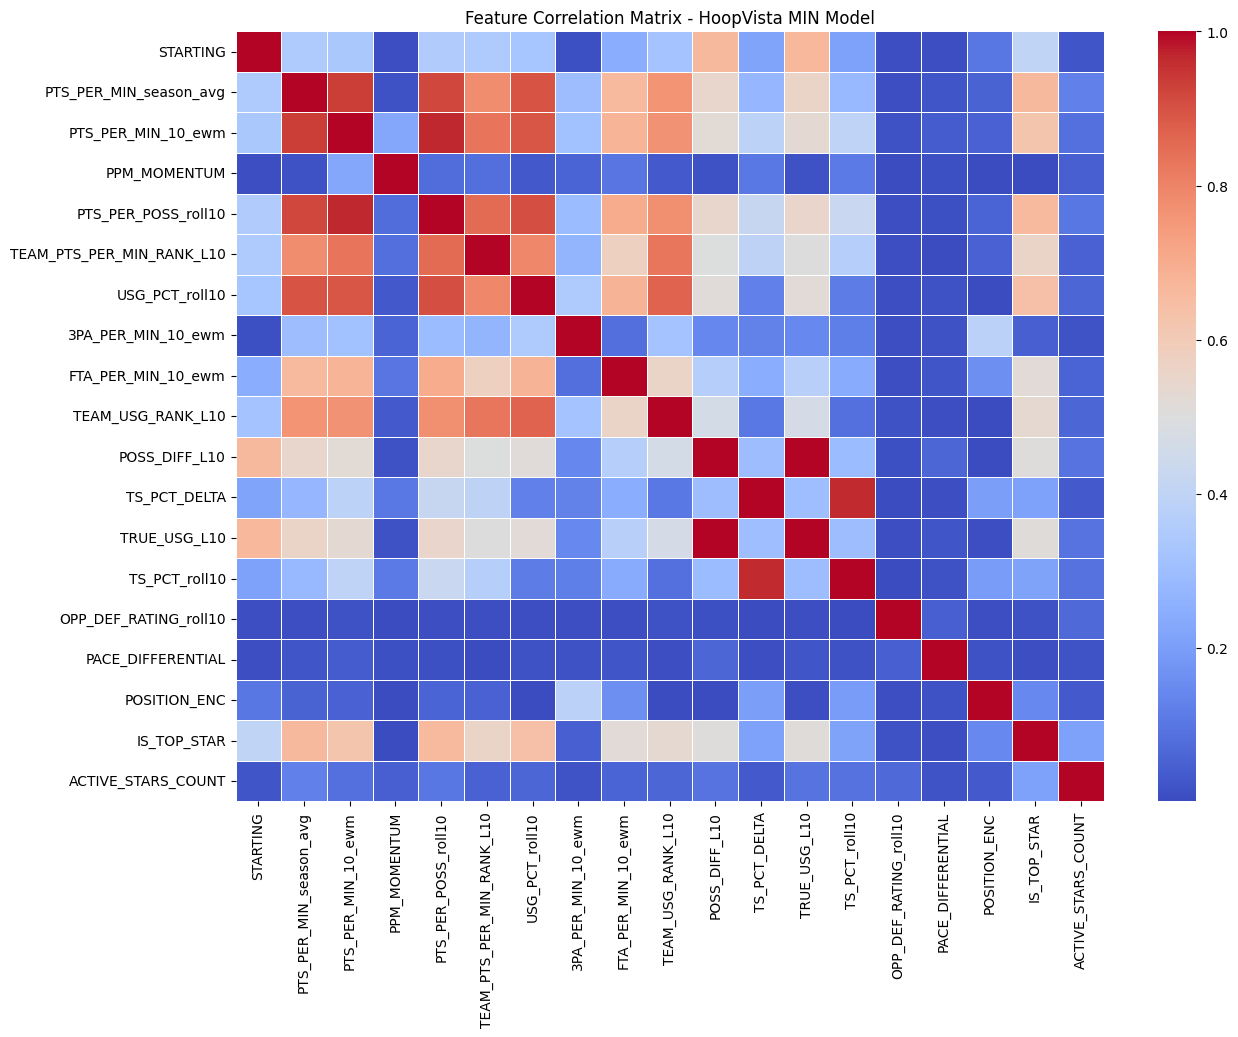

--- High Correlation Report (Threshold > 0.85) ---
TRUE_USG_L10 <-> POSS_DIFF_L10: 0.9966
PTS_PER_POSS_roll10 <-> PTS_PER_MIN_10_ewm: 0.9687
TS_PCT_roll10 <-> TS_PCT_DELTA: 0.9611
PTS_PER_MIN_10_ewm <-> PTS_PER_MIN_season_avg: 0.9361
PTS_PER_POSS_roll10 <-> PTS_PER_MIN_season_avg: 0.9190
USG_PCT_roll10 <-> PTS_PER_POSS_roll10: 0.9090
USG_PCT_roll10 <-> PTS_PER_MIN_season_avg: 0.8953
USG_PCT_roll10 <-> PTS_PER_MIN_10_ewm: 0.8933
TEAM_USG_RANK_L10 <-> USG_PCT_roll10: 0.8677
TEAM_PTS_PER_MIN_RANK_L10 <-> PTS_PER_POSS_roll10: 0.8547


['PTS_PER_MIN_10_ewm',
 'PTS_PER_POSS_roll10',
 'TEAM_PTS_PER_MIN_RANK_L10',
 'USG_PCT_roll10',
 'TEAM_USG_RANK_L10',
 'TRUE_USG_L10',
 'TS_PCT_roll10']

In [8]:
import seaborn as sns

def analyze_correlations(df, features, threshold=0.85):
    """
    Analyzes feature correlations to identify redundancy in the MIN model.
    """
    # Calculate correlation matrix
    corr_matrix = df[features].corr().abs()
    
    # Create a mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Identify features with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Plotting the Heatmap
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title(f'Feature Correlation Matrix - HoopVista MIN Model')
    plt.show()
    
    # Detailed report of high correlations
    print(f"--- High Correlation Report (Threshold > {threshold}) ---")
    high_corr_pairs = []
    for col in upper.columns:
        connected = upper.index[upper[col] > threshold].tolist()
        for c in connected:
            high_corr_pairs.append((col, c, upper.loc[c, col]))
            
    if not high_corr_pairs:
        print("No features exceed the correlation threshold.")
    else:
        for f1, f2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
            print(f"{f1} <-> {f2}: {val:.4f}")
            
    return to_drop

# Usage with your specific list
correlated_features = analyze_correlations(df, PPM_FEATURES)
correlated_features

In [9]:
import joblib
from pathlib import Path


bundle = {
    "quantile_models": quantile_models,
    "feature_names": PPM_FEATURES,  # or list(X_train_min.columns)
    "scaler": scaler
}
joblib.dump(bundle, "src/models/saved_models/ppm_quantile_xgb.joblib")

['src/models/saved_models/ppm_quantile_xgb.joblib']

## PPM MODEL + MIN MODEL Analysis

In [4]:
# date = pd.Timestamp.now().normalize()  # midnight today, local tz
# current_date = date.strftime("%Y-%m-%d")

# # target_date = pd.Timestamp("2026-03-26")
# # hist = df[df["GAME_DATE"] < target_date].copy()

# lines_dfs = pd.read_csv('data/raw/player_lines/NBA_DFS_20260403_163051.csv')
# lines_us = pd.read_csv('data/raw/player_lines/NBA_US_20260403_163203.csv')
# lines_dfs = lines_dfs[(lines_dfs['BOOKMAKER'] == 'Underdog') & (lines_dfs['CATEGORY'] == 'player_points')]
# names = lines_dfs['NAME'].unique()
# names

today = datetime.today().strftime('%Y%m%d')  
current_date = datetime.now().strftime('%Y-%m-%d')
target_date = pd.Timestamp("2026-04-11")
hist = df[df["GAME_DATE"] < target_date].copy()

lines_dfs = pd.read_csv('data/raw/player_lines/NBA_DFS_20260411_140648.csv')
lines_dfs = lines_dfs[(lines_dfs['BOOKMAKER'] == 'Underdog') & (lines_dfs['CATEGORY'] == 'player_points')]
names = lines_dfs['NAME'].unique()
names

array(['Bam Adebayo', 'Tyler Herro', 'Jaime Jaquez Jr', 'Davion Mitchell',
       "Kel'el Ware", 'Kawhi Leonard', 'Darius Garland',
       'Bennedict Mathurin', 'Scoot Henderson', 'Jrue Holiday',
       'Deni Avdija', 'Donovan Clingan', 'Toumani Camara',
       'Maxime Raynaud', 'Daeqwon Plowden', 'Devin Carter'], dtype=object)

In [10]:
records = []

for name in names:
    try:
        if name in nameDict:
            name = nameDict[name]

        min_feats = min_pipeline(df, name, current_date)
        if min_feats is None:
            raise ValueError("min_pipeline returned None (need >= 10 games)")

        ppm_feats = ppm_pipeline(df, name, current_date)
        # ppm_pipeline returns a list aligned with PPM_FEATURES / training columns

        min_arr = np.asarray(min_feats, dtype=float).reshape(1, -1)
        ppm_arr = np.asarray(ppm_feats, dtype=float).reshape(1, -1)

        m10 = float(min_quantile_models["q_0.10"].predict(min_arr)[0])
        m50 = float(min_quantile_models["q_0.50"].predict(min_arr)[0])
        m90 = float(min_quantile_models["q_0.90"].predict(min_arr)[0])

        p10 = float(ppm_quantile_models["q_0.10"].predict(ppm_arr)[0])
        p50 = float(ppm_quantile_models["q_0.50"].predict(ppm_arr)[0])
        p90 = float(ppm_quantile_models["q_0.90"].predict(ppm_arr)[0])

        # implied PTS = minutes × PTS per minute (same quantile index on both sides)
        pts10 = m10 * p10
        pts50 = m50 * p50
        pts90 = m90 * p90

        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": m10,
            "PRED_MIN_Q50": m50,
            "PRED_MIN_Q90": m90,
            "PRED_PPM_Q10": p10,
            "PRED_PPM_Q50": p50,
            "PRED_PPM_Q90": p90,
            "PRED_PTS_Q10": pts10,
            "PRED_PTS_Q50": pts50,
            "PRED_PTS_Q90": pts90,
            "PRED_PTS_RANGE_10_90": pts90 - pts10,
        })

    except Exception as e:
        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": np.nan,
            "PRED_MIN_Q50": np.nan,
            "PRED_MIN_Q90": np.nan,
            "PRED_PPM_Q10": np.nan,
            "PRED_PPM_Q50": np.nan,
            "PRED_PPM_Q90": np.nan,
            "PRED_PTS_Q10": np.nan,
            "PRED_PTS_Q50": np.nan,
            "PRED_PTS_Q90": np.nan,
            "PRED_PTS_RANGE_10_90": np.nan,
        })
        print(f"[SKIP] {name}: {e}")

preds_df = pd.DataFrame(records)
preds_df.head()

,PLAYER_NAME,PRED_MIN_Q10,PRED_MIN_Q50,PRED_MIN_Q90,PRED_PPM_Q10,PRED_PPM_Q50,PRED_PPM_Q90,PRED_PTS_Q10,PRED_PTS_Q50,PRED_PTS_Q90,PRED_PTS_RANGE_10_90
0,Bam Adebayo,7.266884,33.650997,44.387238,0.322626,0.586112,1.035865,2.344489,19.723256,45.979205,43.634716
1,Tyler Herro,11.670135,33.478523,44.817150,0.323220,0.583013,1.067012,3.772024,19.518426,47.820424,44.048400
2,Jaime Jaquez Jr.,14.258892,35.336914,43.086315,0.187986,0.521840,1.004989,2.680470,18.440214,43.301279,40.620809
3,Davion Mitchell,14.405640,33.244370,44.759659,0.154667,0.358826,0.800202,2.228082,11.928931,35.816769,33.588687
4,Kel'el Ware,15.144941,33.324505,40.978050,0.108241,0.427532,0.914231,1.639307,14.247293,37.463394,35.824087
